# Aadhaar Operational Landscape Analysis 


**Scope:** Operational landscape analysis of three independent system streams:
- Enrollment entries
- Demographic update entries
- Biometric update entries

> **Important modeling decision:** The three datasets are treated as independent operational streams.
> We do not assume causal relationships, baselines, or correlations between them.



---

## Executive Summary

This project maps the **operational landscape** of Aadhaar-related system activity across India using three independent datasets:
Enrollment, Demographic updates, and Biometric updates.

### What problem are we solving?
Operations teams need to answer:
- **Where** is activity concentrated (by state)?
- **When** does activity spike (by month)?
- **What** is the composition of activity (age groups)?
- **How concentrated** is the workload (Pareto tiers)?
- **Which states** show unusual instability (robust anomalies)?
- **How can we segment states** into operational types (K-means clustering)?

### What makes this analysis “operational”?
We treat each record as a **system entry**, not a dependent transaction.
All insights are **descriptive**, designed to support:
capacity planning, prioritization, and monitoring.


---

## Data Overview & Constraints

### Datasets (Independent Streams)
We analyze three independent operational streams:
1. Enrollment entries
2. Demographic update entries
3. Biometric update entries

### Available columns
- Date
- State
- District
- Pincode
- Age brackets

### Constraints (and how we handled them)
- No SLA, processing status, error codes, or center-level throughput fields → focus is on **distribution + seasonality + concentration + stability**.
- No cross-linking keys between datasets → no correlation/causal modeling by design.



---

## Data Loading from Cleaned Output

### Why this step exists
The notebook loads pre-cleaned and standardized data generated by `main.py`, ensuring consistency and avoiding redundant processing.

### What we do in this section
1. Load cleaned Parquet files for each stream (Enrollment / Demographic / Biometric) from `output/cleaned_data/`
2. Ensure dates are parsed and `month` column is available for time-based aggregation
3. Define stream constants and helper functions

### Output of this section
- Loaded datasets ready for analysis
- Stream definitions and colors for visualizations

In [14]:
# =============================================================================
# AADHAAR OPERATIONAL LANDSCAPE — DIAGNOSTIC NOTEBOOK
# (Loads cleaned data from main.py output)
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# =============================================================================
# LOAD CLEANED DATA (from main.py output)
# =============================================================================

CLEANED_DATA_FOLDER = r"F:/My Data Analyst Projects/UIDAI Project/output/cleaned_data"

# Load the Parquet files generated by main.py
raw = {
    "enrollment": pd.read_parquet(os.path.join(CLEANED_DATA_FOLDER, "enrollment_cleaned.parquet")),
    "demographic": pd.read_parquet(os.path.join(CLEANED_DATA_FOLDER, "demographic_cleaned.parquet")),
    "biometric": pd.read_parquet(os.path.join(CLEANED_DATA_FOLDER, "biometric_cleaned.parquet")),
}

# Ensure dates are parsed (if not already)
for s in ["enrollment", "demographic", "biometric"]:
    if "date" in raw[s].columns:
        raw[s]["date"] = pd.to_datetime(raw[s]["date"], errors="coerce")
        raw[s]["month"] = raw[s]["date"].dt.to_period("M")

# Define streams and colors
STREAMS = ["enrollment", "demographic", "biometric"]
COLORS = {"enrollment": "#2E86AB", "demographic": "#A23B72", "biometric": "#F18F01"}

def detect_age_cols(df):
    return [c for c in df.columns if 'age' in c.lower()]


---
## Analysis 1. State Volume Comparison (All streams)

### Operational question
**Which states carry the highest operational load, and what is the stream-wise contribution?**

### Why it matters
State volume is the primary driver for:
- Staffing allocation
- Infrastructure planning
- Field outreach prioritization
- Governance tiering (Tier 1/2/3)


## State Volume Comparison (All Streams)

,enrollment,demographic,biometric,total_all_streams,share_total_all_streams_pct
state,,,,,
Tamil Nadu,92552,196857,184568,473977,9.598725
Andhra Pradesh,65663,207740,172065,445468,9.021377
Uttar Pradesh,110369,167889,155242,433500,8.779007
Maharashtra,77191,162242,151104,390537,7.908944
West Bengal,76561,169067,130895,376523,7.625140
Karnataka,70198,153957,141227,365382,7.399518
Odisha,47011,105935,99674,252620,5.115923
Kerala,39145,105515,98511,243171,4.924567
Bihar,60567,97621,83398,241586,4.892469


**ipywidgets not available** → showing static Top 25 view.

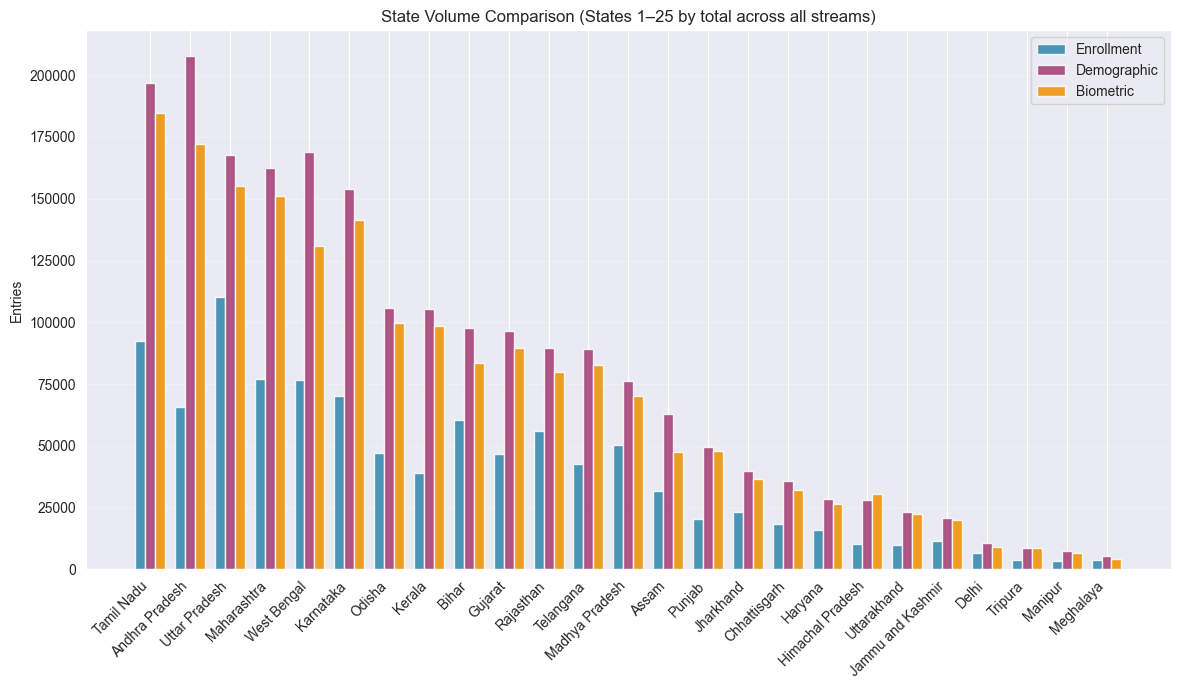

In [15]:
# =============================================================================
# ANALYSIS 1: STATE VOLUME COMPARISON 
# =============================================================================
display(Markdown("## State Volume Comparison (All Streams)"))

def build_state_volume_table(streams_dict):
    by_stream = {s: streams_dict[s].groupby("state").size().rename(s) for s in STREAMS}
    combined = pd.concat(by_stream.values(), axis=1).fillna(0).astype(int)
    combined["total_all_streams"] = combined.sum(axis=1)
    combined = combined.sort_values("total_all_streams", ascending=False)
    total = combined["total_all_streams"].sum()
    combined["share_total_all_streams_pct"] = np.where(total > 0, combined["total_all_streams"] / total * 100, 0)
    return combined

state_tbl = build_state_volume_table(raw)
display(state_tbl.head(10))

def plot_state_volume_window(state_table, start=0, window=20):
    st = state_table.iloc[start:start+window].copy()
    idx = np.arange(len(st))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 7))
    for j, s in enumerate(STREAMS):
        ax.bar(idx + j*width, st[s].values, width=width, label=s.capitalize(), color=COLORS[s], alpha=0.85)

    ax.set_xticks(idx + width)
    ax.set_xticklabels(st.index, rotation=45, ha="right")
    ax.set_ylabel("Entries")
    ax.set_title(f"State Volume Comparison (States {start+1}–{start+len(st)} by total across all streams)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.show()

# ipywidgets slider
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    max_start = max(0, len(state_tbl) - 20)

    @interact(
        start=widgets.IntSlider(value=0, min=0, max=max_start, step=1, description="Start"),
        window=widgets.IntSlider(value=20, min=10, max=40, step=5, description="Window"),
    )
    def _interactive_state_volume(start=0, window=20):
        plot_state_volume_window(state_tbl, start=start, window=window)

except Exception:
    display(Markdown("**ipywidgets not available** → showing static Top 25 view."))
    plot_state_volume_window(state_tbl, start=0, window=25)

### How to read this visualization
- Bars show **entries per state** for each stream.
- States are ordered by **total across all streams**.
- The slider allows exploring the full distribution beyond the top states.

### What to look for 
- **Dominant states**: consistent leaders across streams → predictable load centers.
- **Stream-specific spikes**: a state that is high in one stream but not others → specialized operational load.


### Key Insights 
- Insight 1: "A small set of states accounts for a large share of total operational entries."
- Insight 2: "Some states are operationally specialized—high in biometric stream but mid in others."
- Insight 3: "The long tail (many low-volume states) suggests a tiered operating model is needed."


---
## Analysis 2. Concentration Ratios (Top-5, Top-10, Outside Top-10)

### Operational question
**How concentrated is each stream, and what concentration risk does it create?**

### Why it matters
- High Top-5 share → dependence on a few states (capacity risk).
- High Outside Top-10 share → widespread distribution (coordination + coverage challenge).


In [16]:
# =============================================================================
# ANALYSIS 2: SIMPLE CONCENTRATION RATIOS (STATE LEVEL)
# =============================================================================
display(Markdown("## Concentration Ratios (Top-5 / Top-10 / Outside Top-10)"))

def concentration_ratios(streams_dict, top_n_list=(5, 10)):
    rows = []
    for s in STREAMS:
        counts = streams_dict[s].groupby("state").size().sort_values(ascending=False)
        total = counts.sum()
        rec = {"stream": s, "states": int(counts.size), "total_entries": int(total)}
        for n in top_n_list:
            rec[f"top_{n}_share_pct"] = float((counts.head(n).sum() / total * 100) if total else 0)
        outside = float((counts.iloc[10:].sum() / total * 100) if total and counts.size > 10 else 0)
        rec["outside_top10_share_pct"] = outside
        rows.append(rec)
    return pd.DataFrame(rows)

conc_tbl = concentration_ratios(raw)
display(conc_tbl.round(2))

## Concentration Ratios (Top-5 / Top-10 / Outside Top-10)

,stream,states,total_entries,top_5_share_pct,top_10_share_pct,outside_top10_share_pct
0,enrollment,36,1005889,42.44,70.24,29.76
1,demographic,36,2071151,43.64,70.65,29.35
2,biometric,36,1860876,43.22,70.19,29.81


### Key Insights 
- Stream with highest Top-5 share: <stream> → most concentrated workload.
- Stream with highest Outside Top-10 share: <stream> → most geographically distributed workload.


---
## Analysis 3. Pareto Table & Tiering (Tier 1 / Tier 2 / Tier 3)

### Operational question
**Which states should be managed under different operational tiers?**

### Tier logic (simple & explainable)
- **Tier 1:** states contributing up to first 50% cumulative volume
- **Tier 2:** next states taking cumulative from 50% to 80%
- **Tier 3:** remaining states (80%–100%)

### Why it matters
Tiering converts a long ranking into an operating model:
- Tier 1 → high-capacity, high-governance, frequent review
- Tier 2 → targeted optimization and support
- Tier 3 → lightweight monitoring and coverage assurance


In [17]:
# =============================================================================
# ANALYSIS 3: PARETO TABLE + TIERS (STATE LEVEL)
# =============================================================================
display(Markdown("##  Pareto Table + Tiers (Tier1/Tier2/Tier3)"))

def pareto_tiers_state(df, tier1_cut=50, tier2_cut=80):
    counts = df.groupby("state").size().sort_values(ascending=False)
    total = counts.sum()
    pct = counts / total * 100 if total else counts * 0
    cum_pct = pct.cumsum()
    tier = np.where(cum_pct <= tier1_cut, "Tier 1 (<=50%)",
            np.where(cum_pct <= tier2_cut, "Tier 2 (50-80%)", "Tier 3 (80-100%)"))
    tbl = pd.DataFrame({
        "rank": np.arange(1, len(counts) + 1),
        "state": counts.index,
        "entries": counts.values,
        "share_pct": pct.values,
        "cumulative_pct": cum_pct.values,
        "tier": tier
    })
    return tbl

pareto = {s: pareto_tiers_state(raw[s]) for s in STREAMS}
for s in STREAMS:
    display(Markdown(f"### {s.upper()} — Pareto (Top 15)"))
    display(pareto[s].head(15).round(2))

##  Pareto Table + Tiers (Tier1/Tier2/Tier3)

### ENROLLMENT — Pareto (Top 15)

,rank,state,entries,share_pct,cumulative_pct,tier
0,1,Uttar Pradesh,110369,10.97,10.97,Tier 1 (<=50%)
1,2,Tamil Nadu,92552,9.20,20.17,Tier 1 (<=50%)
2,3,Maharashtra,77191,7.67,27.85,Tier 1 (<=50%)
3,4,West Bengal,76561,7.61,35.46,Tier 1 (<=50%)
4,5,Karnataka,70198,6.98,42.44,Tier 1 (<=50%)
5,6,Andhra Pradesh,65663,6.53,48.97,Tier 1 (<=50%)
6,7,Bihar,60567,6.02,54.99,Tier 2 (50-80%)
7,8,Rajasthan,56159,5.58,60.57,Tier 2 (50-80%)
8,9,Madhya Pradesh,50225,4.99,65.56,Tier 2 (50-80%)
9,10,Odisha,47011,4.67,70.24,Tier 2 (50-80%)


### DEMOGRAPHIC — Pareto (Top 15)

,rank,state,entries,share_pct,cumulative_pct,tier
0,1,Andhra Pradesh,207740,10.03,10.03,Tier 1 (<=50%)
1,2,Tamil Nadu,196857,9.50,19.53,Tier 1 (<=50%)
2,3,West Bengal,169067,8.16,27.70,Tier 1 (<=50%)
3,4,Uttar Pradesh,167889,8.11,35.80,Tier 1 (<=50%)
4,5,Maharashtra,162242,7.83,43.64,Tier 1 (<=50%)
5,6,Karnataka,153957,7.43,51.07,Tier 2 (50-80%)
6,7,Odisha,105935,5.11,56.19,Tier 2 (50-80%)
7,8,Kerala,105515,5.09,61.28,Tier 2 (50-80%)
8,9,Bihar,97621,4.71,65.99,Tier 2 (50-80%)
9,10,Gujarat,96399,4.65,70.65,Tier 2 (50-80%)


### BIOMETRIC — Pareto (Top 15)

,rank,state,entries,share_pct,cumulative_pct,tier
0,1,Tamil Nadu,184568,9.92,9.92,Tier 1 (<=50%)
1,2,Andhra Pradesh,172065,9.25,19.16,Tier 1 (<=50%)
2,3,Uttar Pradesh,155242,8.34,27.51,Tier 1 (<=50%)
3,4,Maharashtra,151104,8.12,35.63,Tier 1 (<=50%)
4,5,Karnataka,141227,7.59,43.22,Tier 1 (<=50%)
5,6,West Bengal,130895,7.03,50.25,Tier 2 (50-80%)
6,7,Odisha,99674,5.36,55.61,Tier 2 (50-80%)
7,8,Kerala,98511,5.29,60.90,Tier 2 (50-80%)
8,9,Gujarat,89531,4.81,65.71,Tier 2 (50-80%)
9,10,Bihar,83398,4.48,70.19,Tier 2 (50-80%)


### Key Insights 
- Tier 1 size tells how many states you must manage tightly to control ~50% of workload.
- Differences across streams show whether operations can share the same tier model or require stream-specific governance.


---

## Analysis 4. State Seasonality Scoreboard (State-level)

### Operational question
**Which states are most seasonal, and when do they peak?**

### Why it matters
- Seasonality supports **calendar-based capacity planning**
- Peak month identification supports **targeted staffing windows**
- Avoids dense heatmaps while preserving interpretability


In [18]:
# =============================================================================
# ANALYSIS 4 (STATE LEVEL): STATE SEASONALITY SCOREBOARD
# =============================================================================
display(Markdown("##  State Seasonality Scoreboard (State-level only)"))

def state_seasonality_metrics(df):
    m = df.groupby(["state", "month"]).size().unstack(fill_value=0)
    mean_ = m.mean(axis=1)
    std_ = m.std(axis=1)
    cv_pct = (std_ / mean_.replace(0, np.nan)) * 100
    peak = m.max(axis=1)
    trough = m.min(axis=1)
    peak_month = m.idxmax(axis=1).astype(str)
    seasonality_strength = ((peak - trough) / mean_.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
    out = pd.DataFrame({
        "total_entries": m.sum(axis=1),
        "mean_monthly": mean_.fillna(0),
        "cv_pct": cv_pct.replace([np.inf, -np.inf], np.nan).fillna(0),
        "peak_month": peak_month,
        "peak_value": peak,
        "trough_value": trough,
        "seasonality_strength": seasonality_strength,
    }).sort_values("total_entries", ascending=False)
    return out

seasonality = {s: state_seasonality_metrics(raw[s]) for s in STREAMS}
for s in STREAMS:
    display(Markdown(f"### {s.upper()} — Top 10 states (total entries + peak month)"))
    display(seasonality[s].head(10)[["total_entries", "peak_month", "peak_value", "seasonality_strength", "cv_pct"]].round(2))


##  State Seasonality Scoreboard (State-level only)

### ENROLLMENT — Top 10 states (total entries + peak month)

,total_entries,peak_month,peak_value,seasonality_strength,cv_pct
state,,,,,
Uttar Pradesh,110369,2025-09,40937,3.33,128.46
Tamil Nadu,92552,2025-09,32646,3.17,128.38
Maharashtra,77191,2025-09,27621,3.22,126.12
West Bengal,76561,2025-09,27966,3.29,128.18
Karnataka,70198,2025-09,24233,3.11,125.08
Andhra Pradesh,65663,2025-09,22114,3.03,125.03
Bihar,60567,2025-09,21457,3.19,126.06
Rajasthan,56159,2025-09,21136,3.39,129.49
Madhya Pradesh,50225,2025-09,17675,3.17,126.05


### DEMOGRAPHIC — Top 10 states (total entries + peak month)

,total_entries,peak_month,peak_value,seasonality_strength,cv_pct
state,,,,,
Andhra Pradesh,207740,2025-12,66929,2.90,122.89
Tamil Nadu,196857,2025-12,60434,2.76,121.32
West Bengal,169067,2025-12,55175,2.94,122.78
Uttar Pradesh,167889,2025-12,53597,2.87,120.44
Maharashtra,162242,2025-12,52200,2.89,121.57
Karnataka,153957,2025-12,49150,2.87,119.62
Odisha,105935,2025-12,32790,2.79,120.15
Kerala,105515,2025-12,34730,2.96,122.43
Bihar,97621,2025-12,29794,2.75,120.45


### BIOMETRIC — Top 10 states (total entries + peak month)

,total_entries,peak_month,peak_value,seasonality_strength,cv_pct
state,,,,,
Tamil Nadu,184568,2025-12,55706,2.61,110.32
Andhra Pradesh,172065,2025-12,49851,2.51,109.14
Uttar Pradesh,155242,2025-12,42504,2.36,108.18
Maharashtra,151104,2025-12,44278,2.54,109.55
Karnataka,141227,2025-12,42796,2.62,109.57
West Bengal,130895,2025-12,36037,2.38,109.47
Odisha,99674,2025-12,28583,2.48,109.27
Kerala,98511,2025-12,30839,2.70,109.60
Gujarat,89531,2025-12,27756,2.68,110.76


### Key Insights 
- Most seasonal states (per stream): <state list> → candidates for time-bound staffing surges.
- If peak months align across many states → national seasonal drivers.
- If peak months differ by state → state-specific calendars needed.


---

## Analysis 5. Robust State Anomaly Monitoring (IQR-based)

### Operational question
**Which states have unusual month-to-month spikes/drops that merit investigation?**

### Method (report-friendly)
We use the **1.5×IQR rule** to flag outlier months per state:
- Lower bound: Q1 − 1.5×IQR
- Upper bound: Q3 + 1.5×IQR  
Outliers are values outside these bounds. [web:329]

### Why it matters
This creates a lightweight monitoring layer:
- A state with many flagged months → operational instability risk
- A state with rare but extreme flags → needs event-based explanation


In [19]:
# =============================================================================
# ANALYSIS 5 (STATE LEVEL): ROBUST ANOMALY COUNTS VIA IQR
# =============================================================================
display(Markdown("## Robust State-level Anomalies (IQR rule)"))

def iqr_anomaly_count_state(df, k=1.5):
    m = df.groupby(["state", "month"]).size().unstack(fill_value=0)
    rows = []
    for state in m.index:
        x = m.loc[state].values.astype(float)
        q1 = np.percentile(x, 25)
        q3 = np.percentile(x, 75)
        iqr = q3 - q1
        low = q1 - k * iqr
        high = q3 + k * iqr
        flags = (x < low) | (x > high)
        months = m.columns.astype(str).tolist()
        flagged_months = [months[i] for i, f in enumerate(flags) if f]
        rows.append({
            "state": state,
            "anomaly_months_count": int(np.sum(flags)),
            "flagged_months": ", ".join(flagged_months) if flagged_months else "",
            "total_entries": float(np.sum(x)),
        })
    return pd.DataFrame(rows).sort_values(["anomaly_months_count", "total_entries"], ascending=False)

anoms = {s: iqr_anomaly_count_state(raw[s], k=1.5) for s in STREAMS}
for s in STREAMS:
    display(Markdown(f"### {s.upper()} — Top 15 states by anomaly-month count"))
    display(anoms[s].head(15))

## Robust State-level Anomalies (IQR rule)

### ENROLLMENT — Top 15 states by anomaly-month count

,state,anomaly_months_count,flagged_months,total_entries
33,Uttar Pradesh,0,,110369.0
30,Tamil Nadu,0,,92552.0
20,Maharashtra,0,,77191.0
35,West Bengal,0,,76561.0
15,Karnataka,0,,70198.0
1,Andhra Pradesh,0,,65663.0
4,Bihar,0,,60567.0
28,Rajasthan,0,,56159.0
19,Madhya Pradesh,0,,50225.0
25,Odisha,0,,47011.0


### DEMOGRAPHIC — Top 15 states by anomaly-month count

,state,anomaly_months_count,flagged_months,total_entries
1,Andhra Pradesh,0,,207740.0
30,Tamil Nadu,0,,196857.0
35,West Bengal,0,,169067.0
33,Uttar Pradesh,0,,167889.0
20,Maharashtra,0,,162242.0
15,Karnataka,0,,153957.0
25,Odisha,0,,105935.0
16,Kerala,0,,105515.0
4,Bihar,0,,97621.0
10,Gujarat,0,,96399.0


### BIOMETRIC — Top 15 states by anomaly-month count

,state,anomaly_months_count,flagged_months,total_entries
30,Tamil Nadu,0,,184568.0
1,Andhra Pradesh,0,,172065.0
33,Uttar Pradesh,0,,155242.0
20,Maharashtra,0,,151104.0
15,Karnataka,0,,141227.0
35,West Bengal,0,,130895.0
25,Odisha,0,,99674.0
16,Kerala,0,,98511.0
10,Gujarat,0,,89531.0
4,Bihar,0,,83398.0


### Key Insights 
- High anomaly-count states: <states> → monitoring priority.
- Compare streams: a state may be unstable in one stream but stable in others → stream-specific operational triggers.


---

## Analysis 6. Age Distribution (Pie Comparison) + Top State by Age-group Share

### Operational question
**What is the age composition of entries in each stream, and which states dominate each age segment?**

### Why it matters
Age composition informs:
- outreach planning
- resource allocation by demographic workload shape
- state-specific targeting by age segment


## Age Distribution Pie Comparision + Top State by Age-group Share

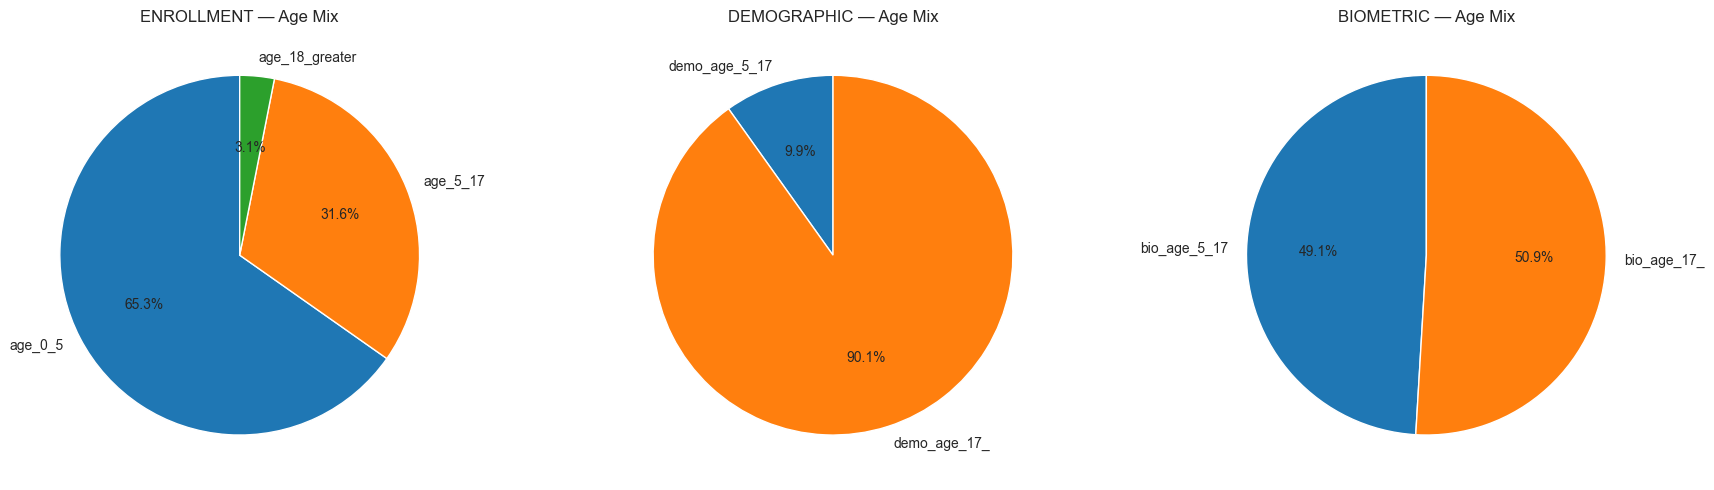

### Top State by Age-group Share (per stream)

,stream,age_group_column,top_state,top_state_share_pct
6,biometric,bio_age_17_,Maharashtra,16.08
5,biometric,bio_age_5_17,Uttar Pradesh,18.14
4,demographic,demo_age_17_,Uttar Pradesh,17.45
3,demographic,demo_age_5_17,Uttar Pradesh,16.25
0,enrollment,age_0_5,Uttar Pradesh,14.69
2,enrollment,age_18_greater,Meghalaya,20.99
1,enrollment,age_5_17,Uttar Pradesh,27.88


In [20]:
# =============================================================================
# ANALYSIS 6: AGE Distribution PIE Chart + TOP STATE BY AGE-GROUP SHARE
# =============================================================================
display(Markdown("## Age Distribution Pie Comparision + Top State by Age-group Share"))

def detect_age_cols(df: pd.DataFrame) -> list:
    cand = [c for c in df.columns if "age" in c.lower()]
    return [c for c in cand if pd.api.types.is_numeric_dtype(df[c])]

age_cols = {s: detect_age_cols(raw[s]) for s in STREAMS}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, s in enumerate(STREAMS):
    cols = age_cols[s]
    if not cols:
        axes[i].axis("off")
        axes[i].text(0.5, 0.5, "No age columns", ha="center", va="center")
        continue
    totals = raw[s][cols].sum()
    axes[i].pie(totals.values, labels=totals.index, autopct="%1.1f%%", startangle=90)
    axes[i].set_title(f"{s.upper()} — Age Mix")
plt.tight_layout()
plt.show()

rows = []
for s in STREAMS:
    cols = age_cols[s]
    if not cols:
        continue
    grouped = raw[s].groupby("state")[cols].sum()
    for c in cols:
        total_c = grouped[c].sum()
        if total_c == 0:
            continue
        share = grouped[c] / total_c * 100
        top_state = share.idxmax()
        rows.append({"stream": s, "age_group_column": c, "top_state": top_state, "top_state_share_pct": float(share.loc[top_state])})
top_age_tbl = pd.DataFrame(rows).sort_values(["stream", "age_group_column"])
display(Markdown("### Top State by Age-group Share (per stream)"))
display(top_age_tbl.round(2))

### Key Insights 
- Dominant age mix differences across streams 
- States leading specific age segments
- Age-driven operational focus opportunities


---

## Analysis 7. State Segmentation (K-means clustering)

### Operational question
**Can we group states into operational types using measurable behavior?**

### Features used (state-level)
- log(1 + total entries)
- monthly volatility (CV)
- seasonality strength
- district footprint (unique district count)
- pincode footprint (unique pincode count)

### Why K-means?
K-means partitions observations into K clusters by minimizing within-cluster variation (inertia),
creating groups of states with similar operational characteristics. 

### Output expectation
Each cluster can be interpreted as an operational persona, such as:
- High-volume stable
- High-volume volatile
- Low-volume wide footprint
- Low-volume stable


## State Clustering (K-means, state-level only)

### ENROLLMENT — Cluster summary

,states,avg_total_entries,avg_monthly_cv,avg_seasonality,avg_districts,avg_pincodes
cluster,,,,,,
0,11,15254.18,1.24,2.95,21.27,362.18
1,3,7816.00,1.35,3.59,18.33,195.67
2,12,66324.50,1.27,3.22,52.58,1257.17
3,10,1875.10,1.28,3.21,8.40,44.30


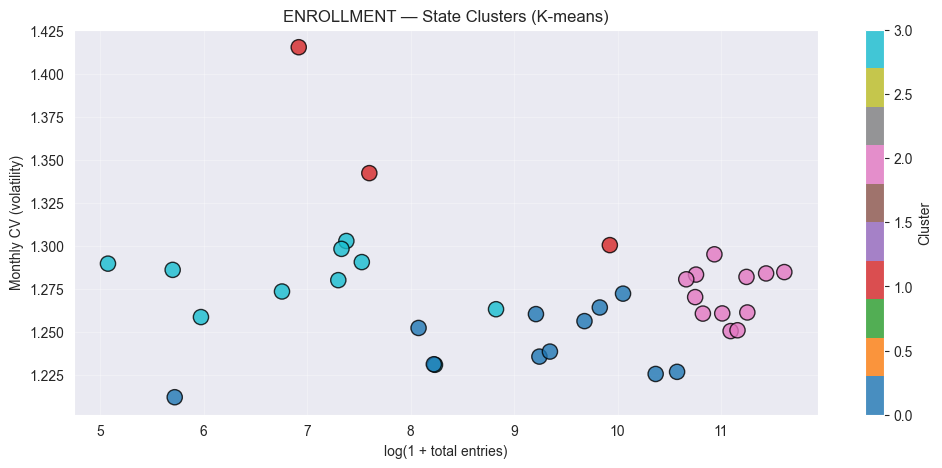

### DEMOGRAPHIC — Cluster summary

,states,avg_total_entries,avg_monthly_cv,avg_seasonality,avg_districts,avg_pincodes
cluster,,,,,,
0,11,27975.73,1.21,2.87,21.18,290.91
1,9,4616.22,1.19,2.62,11.89,46.44
2,13,132167.69,1.21,2.86,49.46,1290.08
3,3,1230.67,1.26,3.14,3.67,15.67


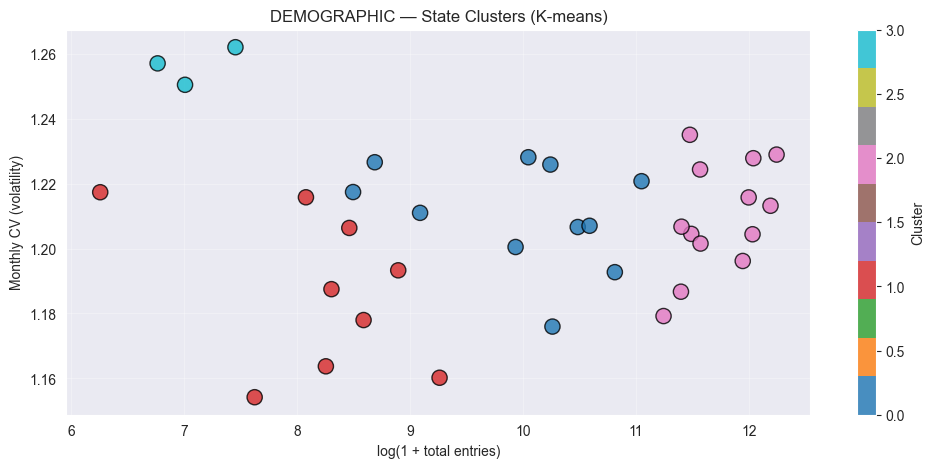

### BIOMETRIC — Cluster summary

,states,avg_total_entries,avg_monthly_cv,avg_seasonality,avg_districts,avg_pincodes
cluster,,,,,,
0,10,14903.20,1.10,2.59,15.00,170.8
1,10,4087.00,1.07,2.33,10.70,49.6
2,6,155850.17,1.09,2.50,57.67,1667.0
3,10,73587.30,1.09,2.55,39.30,820.1


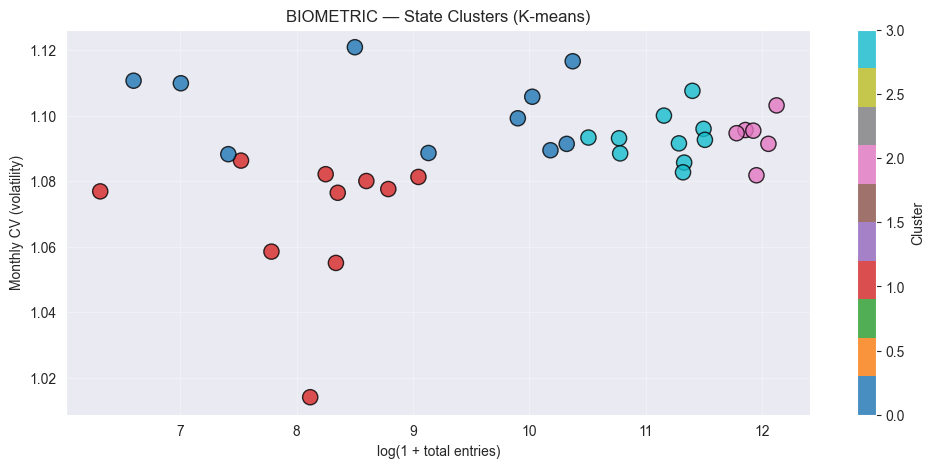

In [21]:
# =============================================================================
# ANALYSIS 7 (STATE LEVEL): K-MEANS CLUSTERING (INTERPRETABLE)
# =============================================================================
display(Markdown("## State Clustering (K-means, state-level only)"))

def build_state_features(df):
    total = df.groupby("state").size().rename("total_entries")
    m = df.groupby(["state", "month"]).size().unstack(fill_value=0)

    mean_ = m.mean(axis=1)
    std_ = m.std(axis=1)
    monthly_cv = (std_ / mean_.replace(0, np.nan)).fillna(0).rename("monthly_cv")

    peak = m.max(axis=1)
    trough = m.min(axis=1)
    seasonality_strength = ((peak - trough) / mean_.replace(0, np.nan)).fillna(0).rename("seasonality_strength")

    district_count = df.groupby("state")["district"].nunique().rename("district_count")
    pincode_count = df.groupby("state")["pincode"].nunique().rename("pincode_count")

    feat = pd.concat([total, monthly_cv, seasonality_strength, district_count, pincode_count], axis=1).fillna(0)
    feat["log_total_entries"] = np.log1p(feat["total_entries"])
    return feat

def kmeans_cluster_states(features_df, k=4, random_state=42):
    X = features_df[["log_total_entries", "monthly_cv", "seasonality_strength", "district_count", "pincode_count"]].copy()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = km.fit_predict(Xs)
    out = features_df.copy()
    out["cluster"] = labels
    return out, km

clusters = {}
for s in STREAMS:
    feat = build_state_features(raw[s])
    clustered, model = kmeans_cluster_states(feat, k=4)
    clusters[s] = clustered

    display(Markdown(f"### {s.upper()} — Cluster summary"))
    display(clustered.groupby("cluster").agg(
        states=("cluster", "size"),
        avg_total_entries=("total_entries", "mean"),
        avg_monthly_cv=("monthly_cv", "mean"),
        avg_seasonality=("seasonality_strength", "mean"),
        avg_districts=("district_count", "mean"),
        avg_pincodes=("pincode_count", "mean"),
    ).round(2))

    fig, ax = plt.subplots(figsize=(12, 5))
    sc = ax.scatter(
        clustered["log_total_entries"], clustered["monthly_cv"],
        c=clustered["cluster"], cmap="tab10", s=120, alpha=0.8, edgecolors="black"
    )
    ax.set_xlabel("log(1 + total entries)")
    ax.set_ylabel("Monthly CV (volatility)")
    ax.set_title(f"{s.upper()} — State Clusters (K-means)")
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label="Cluster")
    plt.show()


### Cluster Interpretation
- **Cluster 0: High-Volume Stable** → States with high total entries and low monthly volatility (CV); represents consistent, predictable operational load centers (e.g., major states like Uttar Pradesh or Maharashtra).
- **Cluster 1: High-Volume Volatile** → States with high total entries but high monthly volatility (CV); indicates fluctuating demand, possibly due to seasonal events or policy changes (e.g., states with enrollment spikes).
- **Cluster 2: Low-Volume Wide Footprint** → States with low total entries but high district/pincode counts; suggests broad geographic coverage with decentralized, low-intensity operations (e.g., large but sparsely populated states).
- **Cluster 3: Low-Volume Stable** → States with low total entries and low volatility; minimal operational load with steady, predictable patterns (e.g., smaller states with stable demographics).

### Operational Actions by Cluster
- **High-Volume Stable** → Optimize efficiency, standardize staffing, and focus on process improvements to handle consistent demand.
- **High-Volume Volatile** → Maintain buffer capacity, implement monthly monitoring, and prepare contingency plans for demand surges.
- **Low-Volume Wide Footprint** → Develop coverage strategies, use decentralized support, and prioritize outreach to ensure equitable service.
- **Low-Volume Stable** → Apply lightweight monitoring, reduce resource allocation, and automate routine tasks for cost efficiency.

---

## Final Analysis Summary: One-page KPI Pack (Per Stream)

This section consolidates the project into a single operational snapshot for decision-makers:
- Total entries
- Top state + share
- Peak month + entries
- Concentration (Top-5, Top-10)
- Average state volatility (CV)
- Seasonality strength
- # states with anomalies
- Tier 1/2/3 counts


In [22]:
# =============================================================================
# ONE-PAGE KPI PACK (PER STREAM)
# =============================================================================
display(Markdown("## One-page KPI Pack (per stream)"))

def top_state_share(df):
    counts = df.groupby("state").size().sort_values(ascending=False)
    total = counts.sum()
    return (counts.index[0], float(counts.iloc[0] / total * 100)) if total else (None, 0.0)

def peak_month(df):
    s = df.groupby("month").size().sort_index()
    return (str(s.idxmax()), int(s.max())) if len(s) else (None, 0)

dashboard_rows = []
conc_idx = conc_tbl.set_index("stream")
for s in STREAMS:
    df = raw[s]
    ts, tsp = top_state_share(df)
    pm, pmv = peak_month(df)
    tier_counts = pareto[s]["tier"].value_counts()

    dashboard_rows.append({
        "stream": s,
        "total_entries": int(len(df)),
        "states": int(df["state"].nunique(dropna=True)),
        "districts": int(df["district"].nunique(dropna=True)),
        "pincodes": int(df["pincode"].nunique(dropna=True)),
        "top_state": ts,
        "top_state_share_pct": round(tsp, 2),
        "peak_month": pm,
        "peak_month_entries": pmv,
        "top_5_share_pct": round(float(conc_idx.loc[s, "top_5_share_pct"]), 2),
        "top_10_share_pct": round(float(conc_idx.loc[s, "top_10_share_pct"]), 2),
        "avg_state_volatility_cv_pct": round(float(seasonality[s]["cv_pct"].mean()), 2),
        "avg_state_seasonality_strength": round(float(seasonality[s]["seasonality_strength"].mean()), 3),
        "states_with_any_anomaly": int((anoms[s]["anomaly_months_count"] > 0).sum()),
        "tier1_states": int(tier_counts.get("Tier 1 (<=50%)", 0)),
        "tier2_states": int(tier_counts.get("Tier 2 (50-80%)", 0)),
        "tier3_states": int(tier_counts.get("Tier 3 (80-100%)", 0)),
        "clusters_k": int(clusters[s]["cluster"].nunique()),
    })

dashboard = pd.DataFrame(dashboard_rows)
display(dashboard)

## One-page KPI Pack (per stream)

,stream,total_entries,states,districts,pincodes,top_state,top_state_share_pct,peak_month,peak_month_entries,top_5_share_pct,top_10_share_pct,avg_state_volatility_cv_pct,avg_state_seasonality_strength,states_with_any_anomaly,tier1_states,tier2_states,tier3_states,clusters_k
0,enrollment,1006029,36,985,19463,Uttar Pradesh,10.97,2025-09,356059,42.44,70.24,127.13,3.166,0,6,6,24,4
1,demographic,2071700,36,983,19742,Andhra Pradesh,10.03,2025-12,657609,43.64,70.65,120.78,2.824,0,5,7,24,4
2,biometric,1861108,36,974,19707,Tamil Nadu,9.92,2025-12,543758,43.22,70.19,108.90,2.492,0,5,7,24,4


---
## Recommendations based on Data Analysis

### 1) Capacity allocation (state)
- Prioritize Tier 1 states for staffing + infra due to majority workload coverage.
- Use stream-wise differences to plan separate operational tracks if needed.

### 2) Calendar planning (month)
- Staff up for peak months visible in the national trend.
- For states with strong seasonality, implement state-specific surge plans.

### 3) Monitoring strategy (stability)
- Create a monthly monitoring list from anomaly-heavy states (IQR flags).
- Investigate flagged months using external context (campaigns, policy deadlines, seasonal events).

### 4) Cluster-driven governance
- Assign a playbook per cluster instead of managing 28+ states individually.
- Review cluster membership quarterly as data expands.
